## 1. Setup and Imports

In [1]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# METEOR Interface (new simplified API)
from meteor import MeteorInterface

print("✅ Imports complete")

✅ Imports complete


## 2. Initialize and Train Emulator

The `MeteorInterface` handles all the complexity:
- Data loading from CMIP6
- Pattern scaling model training
- Noise model training
- Variable-specific transforms (precipitation → Gamma distribution)

In [2]:
# Create emulator for both temperature and precipitation
emulator = MeteorInterface.from_cmip6(
    model='NorESM2-MM',
    variables=['tas', 'pr'],
    cache_dir='../cache'
)

print(f"Emulator created for: {emulator.variables}")
print(f"TAS transform: {emulator.transforms['tas'].transform_type}")
print(f"PR transform: {emulator.transforms['pr'].transform_type} ")

Emulator created for: ['tas', 'pr']
TAS transform: None
PR transform: gamma 


In [3]:
# Define regions and points
regions = ['NEU', 'NSA', 'EAS']
region_names = {
    'NEU': 'Northern Europe',
    'NSA': 'Northern South America',
    'EAS': 'East Asia'
}

cities = {
    'Oslo': {'lat': 59.9, 'lon': 10.8},
    'Delhi': {'lat': 28.6, 'lon': 77.2},
    #'Santiago': {'lat': -33.4, 'lon': 289.3},  # -70.7°W = 289.3°E
    'Cairo': {'lat': 30.0, 'lon': 31.2},
    'Beijing': {'lat': 39.9, 'lon': 116.4}
}

print(f"Regions: {', '.join(regions)}")
print(f"Cities: {', '.join(cities.keys())}")

Regions: NEU, NSA, EAS
Cities: Oslo, Delhi, Cairo, Beijing


In [4]:
# Train models (uses cached models if available)
emulator.train(auto=True, verbose=True)

Training METEOR emulator for NorESM2-MM
Variables: tas, pr

🔧 Training TAS...
   → Training pattern scaling model...
      ⚠️  Cache miss: Model name mismatch: expected 'cmip6-NorESM2-MM-aer', found 'cmip6-NorESM2-MM-aer-tas'
🔧 Preparing pattern scaling training data for NorESM2-MM...


   ✅ Training data prepared for experiments: ['base', 'co2x4', 'ssp245', 'sulxanom']
📥 Loading CICERO-SCM forcing data for ssp245...
   ✅ Loaded 801 concentration records
   ✅ Loaded 751 emission records
   ✅ Config: 1750-2100, emissions start: 1850
📦 Loading cached pattern scaling model from ../cache/pattern_scaling/cmip6-NorESM2-MM-aer-tas_pattern_scaling.pkl
✅ Pattern scaling model loaded from ../cache/pattern_scaling/cmip6-NorESM2-MM-aer-tas_pattern_scaling.pkl
   → Training noise model...
Model loaded from ../cache/noise_models/NorESM2-MM_tas_noise_model.pkl
      ✓ Using cached noise model
   ✅ TAS training complete

🔧 Training PR...
   → Training pattern scaling model...
      ⚠️  Cache miss: Model name mismatch: expected 'cmip6-NorESM2-MM-aer', found 'cmip6-NorESM2-MM-aer-pr'
🔧 Preparing pattern scaling training data for NorESM2-MM...


   ✅ Training data prepared for experiments: ['base', 'co2x4', 'ssp245', 'sulxanom']
📥 Loading CICERO-SCM forcing data for ssp245...
   ✅ Loaded 801 concentration records
   ✅ Loaded 751 emission records
   ✅ Config: 1750-2100, emissions start: 1850
📦 Loading cached pattern scaling model from ../cache/pattern_scaling/cmip6-NorESM2-MM-aer-pr_pattern_scaling.pkl
✅ Pattern scaling model loaded from ../cache/pattern_scaling/cmip6-NorESM2-MM-aer-pr_pattern_scaling.pkl
   → Training noise model...
Model loaded from ../cache/noise_models/NorESM2-MM_pr_noise_model.pkl
      ✓ Using cached noise model
   → Fitting gamma transform...
      Reason: Ensure positive-only values (precipitation cannot be negative)
   ✅ PR training complete

✅ All variables trained successfully


## 3. Define Locations

**Regions (AR6):**
- NEU: Northern Europe
- GIC: Greenland/Iceland
- NSA: Northern South America
- EAS: East Asia

**Cities:**
- Oslo: 59.9°N, 10.8°E
- Delhi: 28.6°N, 77.2°E
- Santiago: -33.4°S, -70.7°W (289.3°E)
- Beijing: 39.9°N, 116.4°E

## 4. Generate Ensemble

Generate 100 realizations with:
- Global mean
- 4 regional means
- 4 point locations
- Heating degree days for temperature

In [5]:
# Build aggregation list
timeseries = ['global']
timeseries += [f'regional:{r}' for r in regions]
timeseries += [f"point:{cities[c]['lat']},{cities[c]['lon']}" for c in cities.keys()]

print(f"Generating {len(timeseries)} spatial aggregations:")
for ts in timeseries:
    print(f"  - {ts}")

Generating 8 spatial aggregations:
  - global
  - regional:NEU
  - regional:NSA
  - regional:EAS
  - point:59.9,10.8
  - point:28.6,77.2
  - point:30.0,31.2
  - point:39.9,116.4


In [6]:
# Reload the meteor_interface module to pick up recent changes
import importlib
import meteor.meteor_interface
importlib.reload(meteor.meteor_interface)
from meteor import MeteorInterface
print("✅ Module reloaded")

✅ Module reloaded


In [7]:
# Generate ensemble with custom EU NECP emissions
# Note: This scenario runs 1750-2050, so we'll generate to 2050
ensemble_custom = emulator.generate(
    scenario={
        'emissions': 'notebook_data/eu_necp_ltt_em_gases_vupdate_2024_WMO_added_new_em_DiamondGCM-Europe.txt',
        'name': 'EU_NECP_2024'
    },
    start_year=1850,
    end_year=2050,  # Match emissions data availability
    n_realizations=50,  # Fewer realizations for demo
    timeseries=['global', 'regional:NEU'],
    verbose=True
)

print(f"\n✅ Custom scenario ensemble generated!")
print(f"Scenario: {ensemble_custom.metadata['scenario']}")
print(f"Variables: {ensemble_custom.metadata['variables']}")

Generating ensemble for EU_NECP_2024
  Years: 1850-2050
  Realizations: 50

📊 Generating TAS...
   → Time series: 2 aggregations
      → Computing pattern scaling for tas, custom scenario 'EU_NECP_2024'...
      → Loaded emissions from eu_necp_ltt_em_gases_vupdate_2024_WMO_added_new_em_DiamondGCM-Europe.txt
      → Loaded concentrations from ssp245_conc_RCMIP.txt
      → Emissions data ends at 2050, extending to 2100 (holding final values)


11
12
113
114
115
22
141
123
142


      → Loading CMIP6 training data for ssp245...
      → Converting tas to anomalies from piControl baseline...
      → Generating 50 stochastic PC realizations...
      • global
      • regional:NEU


   ✅ TAS complete

📊 Generating PR...
   → Time series: 2 aggregations
      → Computing pattern scaling for pr, custom scenario 'EU_NECP_2024'...
      → Loaded emissions from eu_necp_ltt_em_gases_vupdate_2024_WMO_added_new_em_DiamondGCM-Europe.txt
      → Loaded concentrations from ssp245_conc_RCMIP.txt
      → Emissions data ends at 2050, extending to 2100 (holding final values)
11
12
113
114
115
22
141
123
142
      → Loading CMIP6 training data for ssp245...
      → Generating 50 stochastic PC realizations...
      • global
      • regional:NEU
   ✅ PR complete

✅ Generation complete

✅ Custom scenario ensemble generated!
Scenario: EU_NECP_2024
Variables: ['tas', 'pr']


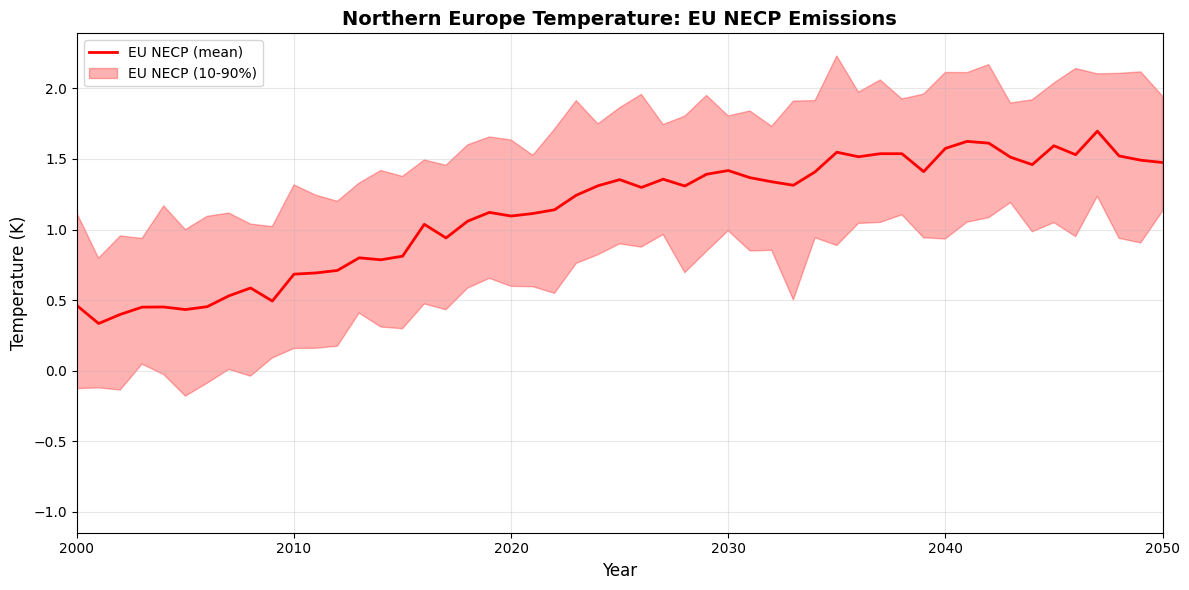

In [8]:
# Compare SSP245 vs EU NECP for Northern Europe temperature
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

# Extract NEU regional data
custom_neu = ensemble_custom['tas'].timeseries['regional:NEU']

# Resample to annual for cleaner plot
def resample_annual(data):
    """Resample monthly to annual means"""
    n_years = len(data) // 12
    return data[:n_years*12].reshape(n_years, 12).mean(axis=1)


# EU NECP (1850-2050)
custom_annual = np.array([resample_annual(real) for real in custom_neu])
years_custom_annual = np.arange(1850, 1850 + len(custom_annual[0]))

ax.plot(years_custom_annual, custom_annual.mean(axis=0), 'r-', linewidth=2, label='EU NECP (mean)')
ax.fill_between(years_custom_annual,
                 np.percentile(custom_annual, 10, axis=0),
                 np.percentile(custom_annual, 90, axis=0),
                 alpha=0.3, color='red', label='EU NECP (10-90%)')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Temperature (K)', fontsize=12)
ax.set_title('Northern Europe Temperature: EU NECP Emissions', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(2000, 2050)

plt.tight_layout()
plt.show()


## 5. Define GCAM Regions

Define custom regions matching the 32 GCAM regions with approximate lat/lon bounding boxes.

In [39]:
# Define GCAM custom regions with approximate lat/lon bounding boxes
gcam_regions_org = {
    'USA': {'lat': (25, 50), 'lon': (-125, -65)},
    'Africa_Eastern': {'lat': (-12, 15), 'lon': (30, 50)},
    'Africa_Northern': {'lat': (15, 37), 'lon': (-17, 50)},
    'Africa_Southern': {'lat': (-35, -12), 'lon': (15, 35)},
    'Africa_Western': {'lat': (4, 15), 'lon': (-17, 16)},
    'Australia_NZ': {'lat': (-47, -10), 'lon': (110, 180)},
    'Brazil': {'lat': (-33, 5), 'lon': (-74, -34)},
    'Canada': {'lat': (41, 83), 'lon': (-141, -52)},
    'Central_America_Caribbean': {'lat': (7, 33), 'lon': (-118, -60)},
    'Central_Asia': {'lat': (35, 55), 'lon': (46, 87)},
    'China': {'lat': (18, 53), 'lon': (73, 135)},
    'EU_12': {'lat': (42, 58), 'lon': (-10, 30)},  # Eastern European EU members
    'EU_15': {'lat': (36, 60), 'lon': (-10, 15)},  # Western European EU members
    'Europe_Eastern': {'lat': (44, 52), 'lon': (20, 40)},  # Non-EU Eastern Europe
    'Europe_Non_EU': {'lat': (42, 47), 'lon': (13, 23)},  # Balkans
    'European_Free_Trade': {'lat': (46, 71), 'lon': (5, 31)},  # Norway, Switzerland, Iceland
    'India': {'lat': (8, 35), 'lon': (68, 97)},
    'Indonesia': {'lat': (-11, 6), 'lon': (95, 141)},
    'Japan': {'lat': (24, 46), 'lon': (123, 146)},
    'Mexico': {'lat': (14, 33), 'lon': (-117, -86)},
    'Middle_East': {'lat': (12, 42), 'lon': (34, 63)},
    'Pakistan': {'lat': (23, 37), 'lon': (60, 77)},
    'Russia': {'lat': (41, 82), 'lon': (19, 180)},
    'South_Africa': {'lat': (-35, -22), 'lon': (16, 33)},
    'South_America_Northern': {'lat': (-5, 12), 'lon': (-81, -50)},  # Colombia, Venezuela, Guyana region
    'South_America_Southern': {'lat': (-56, -27), 'lon': (-75, -53)},  # Chile, Argentina south
    'South_Asia': {'lat': (5, 30), 'lon': (79, 93)},  # Bangladesh, Sri Lanka region
    'South_Korea': {'lat': (33, 43), 'lon': (124, 132)},
    'Southeast_Asia': {'lat': (0, 28), 'lon': (92, 108)},  # Thailand, Vietnam, Myanmar
    'Taiwan': {'lat': (21, 26), 'lon': (119, 122)},
    'Argentina': {'lat': (-55, -21), 'lon': (-73, -53)},
    'Colombia': {'lat': (-4, 13), 'lon': (-79, -66)}
}

def convert_region_to_360(region_def):
    """Convert region definition from -180/180 to 0-360 longitude"""
    lat = region_def['lat']
    lon_min, lon_max = region_def['lon']
    
    # Convert negative longitudes to 0-360 format
    if lon_min < 0:
        lon_min = lon_min + 360
    if lon_max < 0:
        lon_max = lon_max + 360
    
    return {'lat': lat, 'lon': (lon_min, lon_max)}

# Create converted version of GCAM regions
gcam_regions = {
    name: convert_region_to_360(region_def) 
    for name, region_def in gcam_regions_org.items()
}


## 6. Test Custom Regions with GCAM

In [10]:
# Reload modules to pick up custom regions fix
import importlib
import meteor.prpatt
import meteor.meteor_interface
importlib.reload(meteor.prpatt)
importlib.reload(meteor.meteor_interface)
from meteor import MeteorInterface, create_region_mask
print("✅ Modules reloaded with custom regions support")

✅ Modules reloaded with custom regions support


In [45]:
# Build timeseries list for all GCAM regions
timeseries = ['global']
timeseries += [f'regional:custom:{region}' for region in gcam_regions.keys()]

print(f"Generating timeseries for {len(timeseries)} locations:")
print(f"  - global")
print(f"  - {len(gcam_regions)} GCAM regions")

# Generate ensemble
ensemble = emulator.generate(
    scenario={
        'emissions': 'notebook_data/eu_necp_ltt_em_gases_vupdate_2024_WMO_added_new_em_DiamondGCM-Europe.txt',
        'name': 'EU_NECP_2024'
    },
    start_year=2020,
    end_year=2050,
    n_realizations=10,
    timeseries=timeseries,
    custom_regions=gcam_regions,
    verbose=True
)

print(f"\n✅ Ensemble generated for all GCAM regions!")

Generating timeseries for 33 locations:
  - global
  - 32 GCAM regions
Generating ensemble for EU_NECP_2024
  Years: 2020-2050
  Realizations: 10

📊 Generating TAS...
   → Time series: 33 aggregations
      → Computing pattern scaling for tas, custom scenario 'EU_NECP_2024'...
      → Loaded emissions from eu_necp_ltt_em_gases_vupdate_2024_WMO_added_new_em_DiamondGCM-Europe.txt
      → Loaded concentrations from ssp245_conc_RCMIP.txt
      → Emissions data ends at 2050, extending to 2100 (holding final values)
11
12
113
114
115
22
141
123
142
      → Loading CMIP6 training data for ssp245...
      → Converting tas to anomalies from piControl baseline...
      → Generating 10 stochastic PC realizations...
      • global
      • regional:custom:USA
      • regional:custom:Africa_Eastern
      • regional:custom:Africa_Northern
      • regional:custom:Africa_Southern
      • regional:custom:Africa_Western
      • regional:custom:Australia_NZ
      • regional:custom:Brazil
      • regional:

   ✅ TAS complete

📊 Generating PR...
   → Time series: 33 aggregations
      → Computing pattern scaling for pr, custom scenario 'EU_NECP_2024'...
      → Loaded emissions from eu_necp_ltt_em_gases_vupdate_2024_WMO_added_new_em_DiamondGCM-Europe.txt
      → Loaded concentrations from ssp245_conc_RCMIP.txt
      → Emissions data ends at 2050, extending to 2100 (holding final values)
11
12
113
114
115
22
141
123
142
      → Loading CMIP6 training data for ssp245...
      → Generating 10 stochastic PC realizations...
      • global
      • regional:custom:USA
      • regional:custom:Africa_Eastern
      • regional:custom:Africa_Northern
      • regional:custom:Africa_Southern
      • regional:custom:Africa_Western
      • regional:custom:Australia_NZ
      • regional:custom:Brazil
      • regional:custom:Canada
      • regional:custom:Central_America_Caribbean
      • regional:custom:Central_Asia
      • regional:custom:China
      • regional:custom:EU_12
      • regional:custom:EU_15
  

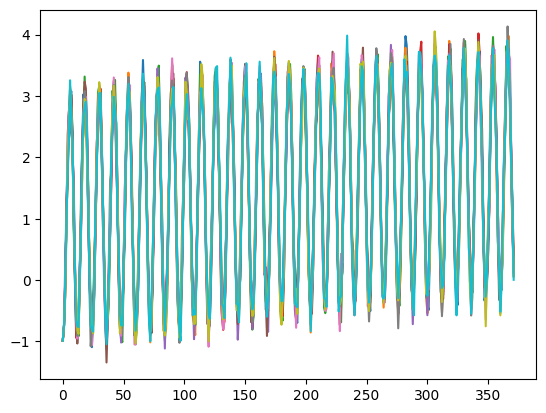

In [46]:
plt.plot(ensemble['tas'].timeseries['regional:custom:Africa_Eastern'].T)


In [47]:
# Helper function to resample monthly to annual
def resample_annual(data):
    """Resample monthly to annual means"""
    n_years = len(data) // 12
    return data[:n_years*12].reshape(n_years, 12).mean(axis=1)

# Prepare data
start_year = 1990
region_names = list(gcam_regions.keys())
n_regions = len(region_names)

# Create years array for plotting
n_months = len(ensemble['tas'].timeseries['global'][0])
n_years = n_months // 12
years = np.arange(start_year, start_year + n_years)

print(f"Preparing data for {n_regions} regions from {start_year} to {start_year + n_years - 1}")
print(f"Shape: {n_months} months = {n_years} years")

Preparing data for 32 regions from 1990 to 2020
Shape: 372 months = 31 years


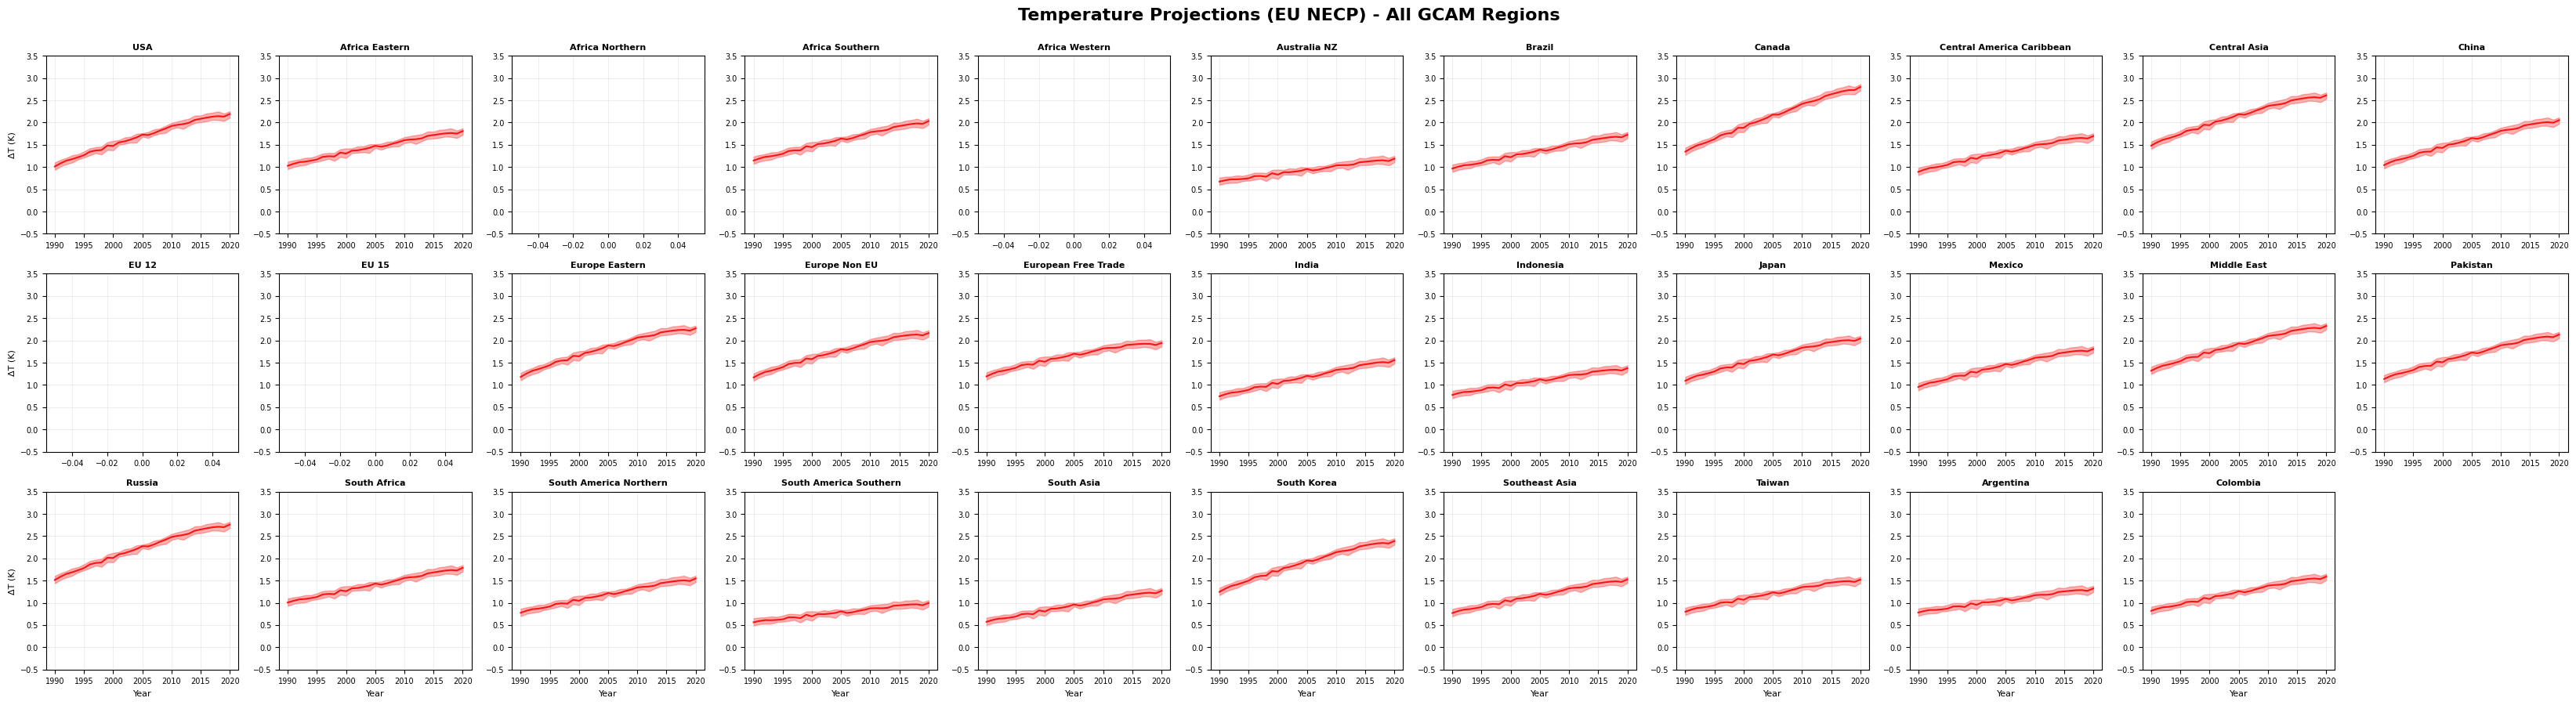

In [49]:
# Plot Temperature for all GCAM regions (3x11 grid)
fig, axes = plt.subplots(3, 11, figsize=(33, 9))
fig.suptitle('Temperature Projections (EU NECP) - All GCAM Regions', 
             fontsize=16, fontweight='bold', y=0.995)

axes_flat = axes.flatten()

for idx, region_name in enumerate(region_names):
    ax = axes_flat[idx]
    
    # Get temperature data for this region
    key = f'regional:custom:{region_name}'
    tas_data = ensemble['tas'].timeseries[key]
    
    # Convert to annual means
    tas_annual = np.array([resample_annual(real) for real in tas_data])
    
    # Calculate statistics
    mean = tas_annual.mean(axis=0)
    p5 = np.percentile(tas_annual, 5, axis=0)
    p95 = np.percentile(tas_annual, 95, axis=0)
    
    # Plot
    ax.plot(years, mean, 'r-', linewidth=1.5, alpha=0.9)
    ax.fill_between(years, p5, p95, alpha=0.3, color='red')
    
    # Formatting
    ax.set_title(region_name.replace('_', ' '), fontsize=8, fontweight='bold')
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.tick_params(labelsize=7)
    
    # Only show y-label on leftmost plots
    if idx % 11 == 0:
        ax.set_ylabel('ΔT (K)', fontsize=8)
    
    # Only show x-label on bottom row
    if idx >= 22:
        ax.set_xlabel('Year', fontsize=8)
    
    # Set consistent y-limits for better comparison
    ax.set_ylim(-0.5, 3.5)

# Hide unused subplots (we have 32 regions, so 1 extra subplot)
for idx in range(n_regions, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Plot Precipitation for all GCAM regions (3x11 grid)
fig, axes = plt.subplots(3, 11, figsize=(33, 9))
fig.suptitle('Precipitation Change (EU NECP) - All GCAM Regions', 
             fontsize=16, fontweight='bold', y=0.995)

axes_flat = axes.flatten()

for idx, region_name in enumerate(region_names):
    ax = axes_flat[idx]
    
    # Get precipitation data for this region
    key = f'regional:custom:{region_name}'
    pr_data = ensemble['pr'].timeseries[key]
    
    # Convert to annual means
    pr_annual = np.array([resample_annual(real) for real in pr_data])
    
    # Calculate statistics
    mean = pr_annual.mean(axis=0)
    p5 = np.percentile(pr_annual, 5, axis=0)
    p95 = np.percentile(pr_annual, 95, axis=0)
    
    # Plot
    ax.plot(years, mean, 'b-', linewidth=1.5, alpha=0.9)
    ax.fill_between(years, p5, p95, alpha=0.3, color='blue')
    
    # Add zero line for reference
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5, alpha=0.5)
    
    # Formatting
    ax.set_title(region_name.replace('_', ' '), fontsize=8, fontweight='bold')
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.tick_params(labelsize=7)
    
    # Only show y-label on leftmost plots
    if idx % 11 == 0:
        ax.set_ylabel('Δ Precip (mm/day)', fontsize=8)
    
    # Only show x-label on bottom row
    if idx >= 22:
        ax.set_xlabel('Year', fontsize=8)
    
    # Set y-limits (will vary by region, but centered on 0)
    y_max = max(abs(p5.min()), abs(p95.max())) * 1.1
    ax.set_ylim(-y_max, y_max)

# Hide unused subplots
for idx in range(n_regions, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [44]:
# Diagnostic: Check what baseline is actually being used
print("=== Checking Temperature Baseline ===")

# Generate a short test ensemble
test_ensemble = emulator.generate(
    scenario='ssp245',
    start_year=2020,
    end_year=2030,  # Just 10 years for quick test
    n_realizations=1,
    timeseries=['global'],
    include_noise=False,  # Climatology only for cleaner test
    verbose=False
)

# Check the actual values
global_tas = test_ensemble['tas'].timeseries['global'][0]
print(f"\nGenerated period: 2020-2030 ({len(global_tas)} months)")
print(f"First value (Jan 2020): {global_tas[0]:.3f} K")
print(f"Mean 2020: {global_tas[:12].mean():.3f} K")
print(f"Mean 2025: {global_tas[60:72].mean():.3f} K")
print(f"\nIs this near zero or showing ~1.2K of warming?")

=== Checking Temperature Baseline ===
11
12
113
114
115
22
141
123
142


11
12
113
114
115
22
141
123
142

Generated period: 2020-2030 (132 months)
First value (Jan 2020): 0.951 K
Mean 2020: 0.951 K
Mean 2025: 1.082 K

Is this near zero or showing ~1.2K of warming?
